In [21]:
from transformers.pipelines import SUPPORTED_TASKS

In [22]:
SUPPORTED_TASKS.items()

dict_items([('audio-classification', {'impl': <class 'transformers.pipelines.audio_classification.AudioClassificationPipeline'>, 'tf': (), 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForAudioClassification'>,), 'default': {'model': {'pt': ('superb/wav2vec2-base-superb-ks', '372e048')}}, 'type': 'audio'}), ('automatic-speech-recognition', {'impl': <class 'transformers.pipelines.automatic_speech_recognition.AutomaticSpeechRecognitionPipeline'>, 'tf': (), 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForCTC'>, <class 'transformers.models.auto.modeling_auto.AutoModelForSpeechSeq2Seq'>), 'default': {'model': {'pt': ('facebook/wav2vec2-base-960h', '22aad52')}}, 'type': 'multimodal'}), ('text-to-audio', {'impl': <class 'transformers.pipelines.text_to_audio.TextToAudioPipeline'>, 'tf': (), 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForTextToWaveform'>, <class 'transformers.models.auto.modeling_auto.AutoModelForTextToSpectrogram'>), 'defau

In [23]:
for k,v in SUPPORTED_TASKS.items():
    print(k,v)

audio-classification {'impl': <class 'transformers.pipelines.audio_classification.AudioClassificationPipeline'>, 'tf': (), 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForAudioClassification'>,), 'default': {'model': {'pt': ('superb/wav2vec2-base-superb-ks', '372e048')}}, 'type': 'audio'}
automatic-speech-recognition {'impl': <class 'transformers.pipelines.automatic_speech_recognition.AutomaticSpeechRecognitionPipeline'>, 'tf': (), 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForCTC'>, <class 'transformers.models.auto.modeling_auto.AutoModelForSpeechSeq2Seq'>), 'default': {'model': {'pt': ('facebook/wav2vec2-base-960h', '22aad52')}}, 'type': 'multimodal'}
text-to-audio {'impl': <class 'transformers.pipelines.text_to_audio.TextToAudioPipeline'>, 'tf': (), 'pt': (<class 'transformers.models.auto.modeling_auto.AutoModelForTextToWaveform'>, <class 'transformers.models.auto.modeling_auto.AutoModelForTextToSpectrogram'>), 'default': {'model': {'pt': ('suno

In [24]:
from transformers import *

In [25]:
pipe = pipeline("text-classification", model="hasancanbiyik/euphemism-detector-multilingual")

loading configuration file config.json from cache at C:\Users\bbfss\.cache\huggingface\hub\models--hasancanbiyik--euphemism-detector-multilingual\snapshots\e3cf34cc5fcb014c9972e053f6afa2bbc74ca8dc\config.json
Model config XLMRobertaConfig {
  "architectures": [
    "XLMRobertaForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "literal",
    "1": "euphemistic"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "euphemistic": 1,
    "literal": 0
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.6",
  "type_vocab_size": 1,
  "use_

In [45]:
pipe("你可真是一个大聪明")

[{'label': 'literal', 'score': 0.9045810699462891}]

# 预先加载模型再创建pipline

这种方式需要同时指定model 和 tokenizer 否则会报错

In [27]:
model = AutoModelForSequenceClassification.from_pretrained("hasancanbiyik/euphemism-detector-multilingual")
tokenizer = AutoTokenizer.from_pretrained("hasancanbiyik/euphemism-detector-multilingual")
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer)

loading configuration file config.json from cache at C:\Users\bbfss\.cache\huggingface\hub\models--hasancanbiyik--euphemism-detector-multilingual\snapshots\e3cf34cc5fcb014c9972e053f6afa2bbc74ca8dc\config.json
Model config XLMRobertaConfig {
  "architectures": [
    "XLMRobertaForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "literal",
    "1": "euphemistic"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "euphemistic": 1,
    "literal": 0
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.6",
  "type_vocab_size": 1,
  "use_

In [28]:
pipe("你好")

[{'label': 'literal', 'score': 0.7689510583877563}]

In [29]:
pipe.model.device

device(type='cuda', index=0)

In [30]:
import torch
import time 
times = []

for i in range(100):
    torch.cuda.synchronize()
    start = time.time()
    pipe("你好")
    torch.cuda.synchronize()
    end = time.time()
    times.append(end-start)
print(sum(times)/len(times))

0.016705150604248046


# 使用GPU跑实验 

In [31]:
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

Device set to use cuda:0


In [32]:
pipe.model.device

device(type='cuda', index=0)

# 确定pipline的参数


In [33]:
qa_pipe = pipeline("question-answering", model="uer/roberta-base-chinese-extractive-qa")

loading configuration file config.json from cache at C:\Users\bbfss\.cache\huggingface\hub\models--uer--roberta-base-chinese-extractive-qa\snapshots\9b02143727b9c4655d18b43a69fc39d5eb3ddd53\config.json
Model config BertConfig {
  "architectures": [
    "BertForQuestionAnswering"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.6",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 21128
}

loading configuration file config.json from cache at C:\Users\bbfss\.cache\huggingface\hub\models--uer--roberta-base-chinese-extractive-qa\snapshots\9b02143727b9c4655d1

In [34]:
qa_pipe

In [35]:
QuestionAnsweringPipeline

transformers.pipelines.question_answering.QuestionAnsweringPipeline

In [36]:
qa_pipe(question="中国的首都是哪里？", context="中国的首都是北京。", max_answer_len=1)

{'score': 0.002925634616985917, 'start': 6, 'end': 7, 'answer': '北'}

# 其他pipeline演示

In [37]:
checkpoint = "google/owlvit-base-patch32"
detector = pipeline(model=checkpoint,task="zero-shot-object-detection", device=0)

loading configuration file config.json from cache at C:\Users\bbfss\.cache\huggingface\hub\models--google--owlvit-base-patch32\snapshots\cbc355fb364588351c5d51c7f74465e8e7ec6f72\config.json
text_config is None. Initializing the OwlViTTextConfig with default values.
vision_config is None. initializing the OwlViTVisionConfig with default values.
Model config OwlViTConfig {
  "architectures": [
    "OwlViTForObjectDetection"
  ],
  "dtype": "float32",
  "initializer_factor": 1.0,
  "logit_scale_init_value": 2.6592,
  "model_type": "owlvit",
  "projection_dim": 512,
  "text_config": {
    "attention_dropout": 0.0,
    "bos_token_id": 0,
    "dropout": 0.0,
    "eos_token_id": 2,
    "hidden_act": "quick_gelu",
    "hidden_size": 512,
    "initializer_factor": 1.0,
    "initializer_range": 0.02,
    "intermediate_size": 2048,
    "layer_norm_eps": 1e-05,
    "max_length": 16,
    "max_position_embeddings": 16,
    "model_type": "owlvit_text_model",
    "num_attention_heads": 8,
    "num_hid

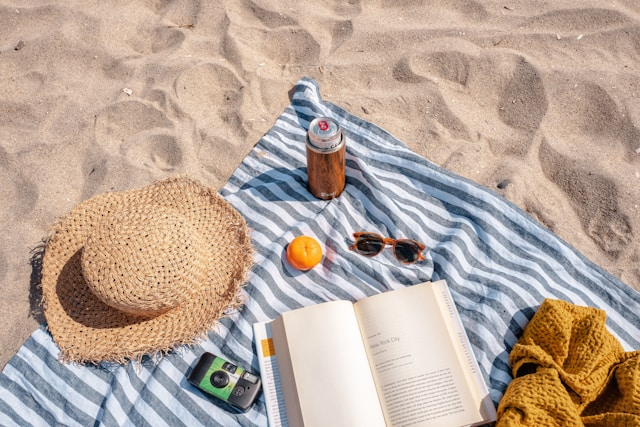

In [38]:
import requests
from PIL import Image

url = "https://unsplash.com/photos/oj0zeY2Ltk4/download?ixid=MnwxMjA3fDB8MXxzZWFyY2h8MTR8fHBpY25pY3xlbnwwfHx8fDE2Nzc0OTE1NDk&force=true&w=640"
im = Image.open(requests.get(url, stream=True).raw)
im

In [42]:
predictions = detector(
    im,
    candidate_labels=["hat", "sunglasses"]
)
predictions

[{'score': 0.25888699293136597,
  'label': 'sunglasses',
  'box': {'xmin': 349, 'ymin': 228, 'xmax': 430, 'ymax': 265}},
 {'score': 0.11237231642007828,
  'label': 'hat',
  'box': {'xmin': 39, 'ymin': 173, 'xmax': 260, 'ymax': 363}}]

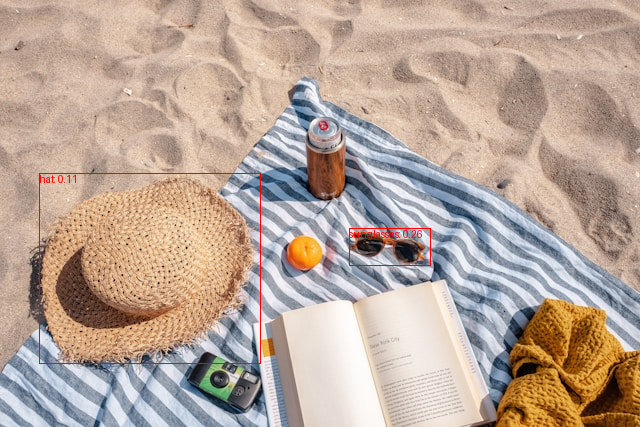

In [ ]:
# 预测结果可视化
from PIL import ImageDraw

draw = ImageDraw.Draw(im)

for prediction in predictions:
    box = prediction["box"]
    label = prediction["label"]
    score = prediction["score"]
    xmin, ymin, xmax, ymax = box.values()
    draw.rectangle((xmin, ymin, xmax, ymax), outline="red", width=1)
    draw.text((xmin, ymin), f"{label}: {round(score,2)}", fill="red")

im

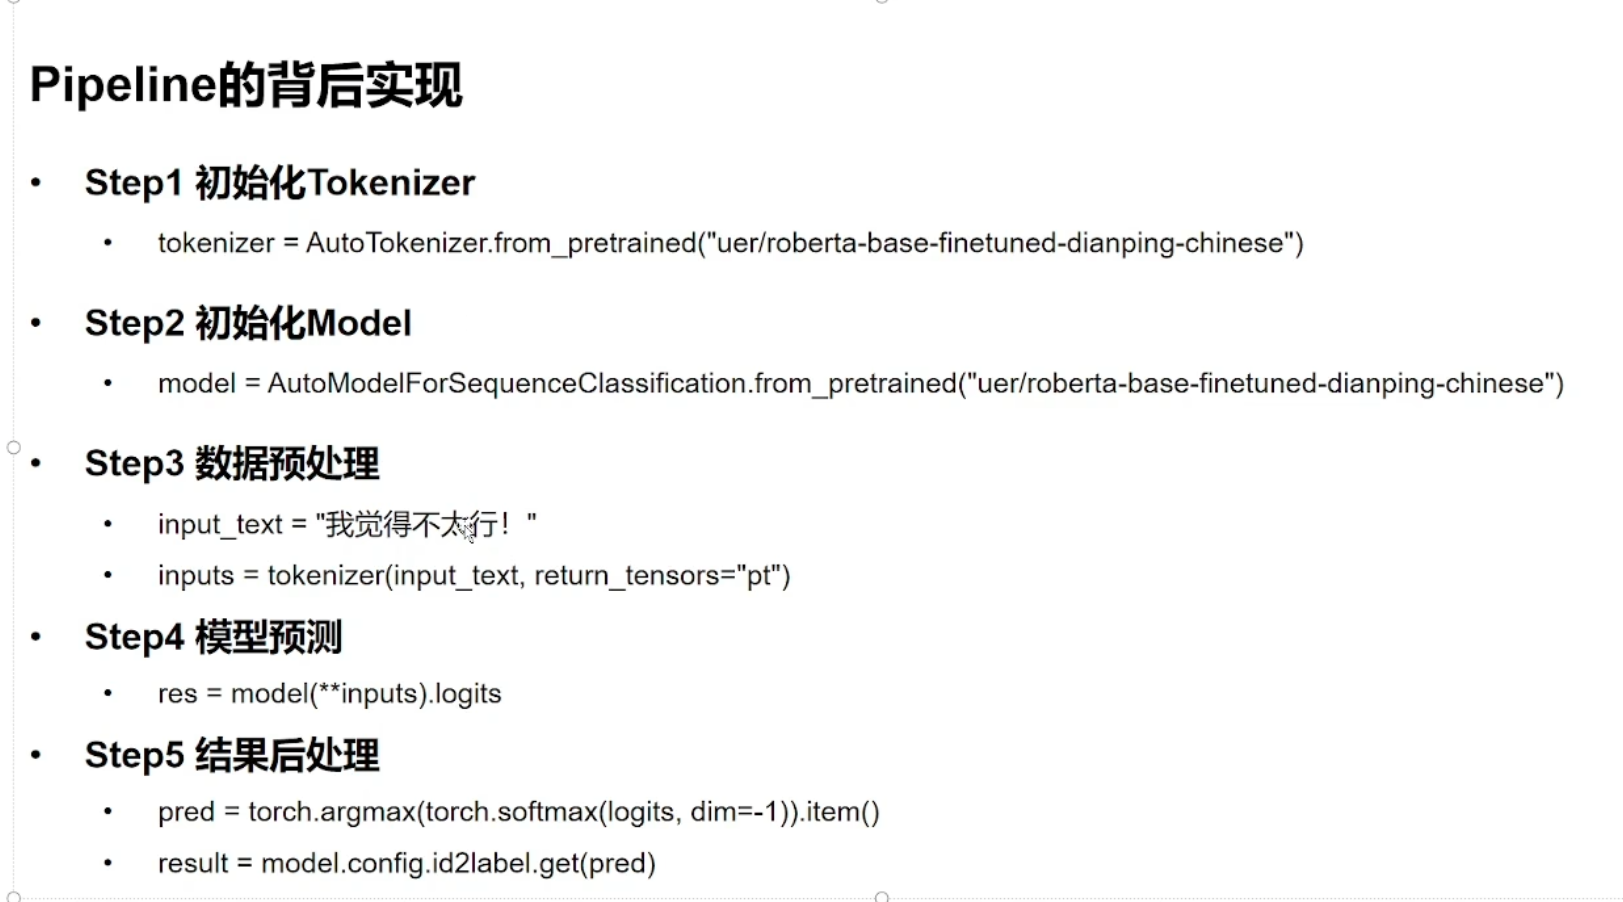

# pipeline实现原理

In [47]:
from transformers import *
import torch

In [51]:
tokenizer = AutoTokenizer.from_pretrained("hasancanbiyik/euphemism-detector-multilingual")
model = AutoModelForSequenceClassification.from_pretrained("hasancanbiyik/euphemism-detector-multilingual")


loading file sentencepiece.bpe.model from cache at None
loading file tokenizer.json from cache at C:\Users\bbfss\.cache\huggingface\hub\models--hasancanbiyik--euphemism-detector-multilingual\snapshots\e3cf34cc5fcb014c9972e053f6afa2bbc74ca8dc\tokenizer.json
loading file added_tokens.json from cache at None
loading file special_tokens_map.json from cache at C:\Users\bbfss\.cache\huggingface\hub\models--hasancanbiyik--euphemism-detector-multilingual\snapshots\e3cf34cc5fcb014c9972e053f6afa2bbc74ca8dc\special_tokens_map.json
loading file tokenizer_config.json from cache at C:\Users\bbfss\.cache\huggingface\hub\models--hasancanbiyik--euphemism-detector-multilingual\snapshots\e3cf34cc5fcb014c9972e053f6afa2bbc74ca8dc\tokenizer_config.json
loading file chat_template.jinja from cache at None
Invalid model-index. Not loading eval results into CardData.
loading configuration file config.json from cache at C:\Users\bbfss\.cache\huggingface\hub\models--hasancanbiyik--euphemism-detector-multilingual\

Attempting to convert .bin model on the fly to safetensors.


In [65]:
input_text = "我觉得不太行！"
inputs = tokenizer(input_text, return_tensors="pt")
inputs

{'input_ids': tensor([[    0,     6, 57105, 44743,  2003,    38,     2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}

In [66]:
# 这里logits 是一个二分类的任务
res = model(**inputs)
res

SequenceClassifierOutput(loss=None, logits=tensor([[ 2.9288, -2.8719]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [67]:
pred = torch.argmax(res.logits, dim=-1)
pred

tensor([0])

In [68]:
model.config.id2label

{0: 'literal', 1: 'euphemistic'}

In [70]:
result = model.config.id2label[pred.item()]
print(result)

literal
